# Experiment C - Reconstruction-Trained Acceleration CNN

**Question:** how much character-discriminative information is recoverable when the classifier is trained directly on reconstructed acceleration?

Strict protocol:

1. Reuse Experiment A's **train / validation / test users** and `class_to_idx` from the A checkpoint.
2. Use the A checkpoint **only for split/class metadata**. Do **not** load A model weights.
3. Fit acceleration normalization using **reconstruction train valid samples only**.
4. Train a new `MaskAwareAccelerationCNN` from scratch on reconstruction train.
5. Select the best epoch using reconstruction validation balanced accuracy.
6. Evaluate on reconstruction test with the shared representation protocol.
7. Use the same selected dataset roots as the A checkpoint; changing the action/sample cohort requires regenerating A.

This notebook is intentionally thin. The executable experiment lives in `scripts/run_experiment_c.py`; the reusable implementation lives in `snn/accel_reconstruction_eval/`.


In [41]:
from __future__ import annotations

from dataclasses import replace
import json
from pathlib import Path
import sys

import pandas as pd
import torch


def find_repository_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate repository root containing the 'snn' directory."
    )


REPOSITORY_ROOT = find_repository_root(Path.cwd())
SCRIPTS_DIR = REPOSITORY_ROOT / "scripts"

if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from snn.accel_reconstruction_eval import experiment_c_config
from run_experiment_c import run_experiment_c

print("Repository root:", REPOSITORY_ROOT)
print("CUDA available:", torch.cuda.is_available())


Repository root: /home/ted/project/writingring-viz
CUDA available: True


## Paths and experiment controls

The reference checkpoint is the Experiment A checkpoint. It is used only to recover the exact user split and class mapping. Experiment C does not reuse its weights or normalization statistics.

Regenerate Experiment A before running B/C/D whenever A's exclusions change. C keeps strict reference mode and has no local cohort or explicit-split override.


In [42]:
# Select the same one or two roots used to produce REFERENCE_A_CHECKPOINT.
# Roots remain separate on disk and are combined only in the shared loader.
# The runner owns model/training logic; this is the only probe switch needed here.
PROBE_VARIANT = "cnn_l"  # one of: cnn_s, cnn_m, cnn_l
DATASET_ROOTS = [
    Path("outputs/action0_rectified/low-pass/aligned-board-events"),
    Path("outputs/action1_rectified/low-pass/aligned-board-events"),
]
REFERENCE_A_CHECKPOINT = Path(
    "notebooks/artifacts/acceleration_cnn_representation/"
    f"{PROBE_VARIANT}/best_acceleration_cnn.pt"
)
OUTPUT_DIR = Path(
    "notebooks/artifacts/experiment_C_reconstruction_trained"
)
if not REFERENCE_A_CHECKPOINT.is_file() and PROBE_VARIANT == "cnn_l":
    REFERENCE_A_CHECKPOINT = Path(
        "notebooks/artifacts/acceleration_cnn_representation/best_acceleration_cnn.pt"
    )

# Keep this False for strict A/B/C comparability.
ALLOW_NEW_SPLIT = False

# Optional training overrides. These defaults match the current CNN baseline.
NUM_EPOCHS = 200
EARLY_STOPPING_PATIENCE = 30
BATCH_SIZE = 128
NUM_WORKERS = 0
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.0
USE_CLASS_WEIGHTS = False
GRAD_CLIP_NORM = None
MAX_TRAIN_BATCHES = None
USE_GPU = True


## Build the Experiment C configuration

Only the training/runtime settings below are modified. The Experiment C domain contract remains fixed as:

- train source = reconstruction
- validation source = reconstruction
- test source = reconstruction
- normalization source = reconstruction train


In [43]:
config = experiment_c_config(
    output_dir=OUTPUT_DIR,
    random_seed=12345,
    probe_variant=PROBE_VARIANT,
)

config = replace(
    config,
    use_gpu=USE_GPU,
    loader=replace(
        config.loader,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
    ),
    training=replace(
        config.training,
        num_epochs=NUM_EPOCHS,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        use_class_weights=USE_CLASS_WEIGHTS,
        grad_clip_norm=GRAD_CLIP_NORM,
        max_train_batches=MAX_TRAIN_BATCHES,
    ),
)
config.validate()
config.to_dict()


{'name': 'C_reconstruction',
 'train_source': 'reconstruction',
 'val_source': 'reconstruction',
 'test_source': 'reconstruction',
 'normalization_source': 'reconstruction',
 'probe_variant': 'cnn_l',
 'training_enabled': True,
 'random_seed': 12345,
 'use_gpu': True,
 'normalization_chunk_segments': 256,
 'split': {'train_fraction': 0.7,
  'val_fraction': 0.15,
  'explicit_train_users': None,
  'explicit_val_users': None,
  'explicit_test_users': None,
  'require_all_users_assigned': True,
  'require_all_labels_in_all_splits': True,
  'excluded_users': (),
  'included_labels': None},
 'loader': {'batch_size': 128,
  'num_workers': 0,
  'pin_memory': None,
  'persistent_workers': None},
 'training': {'num_epochs': 200,
  'learning_rate': 0.0005,
  'weight_decay': 0.0,
  'use_class_weights': False,
  'early_stopping_patience': 30,
  'max_train_batches': None,
  'grad_clip_norm': None},
 'evaluation': {'k_values': (1, 3, 5, 10, 20, 50),
  'knn_k_candidates': (1, 3, 5, 7, 10, 15, 20),
  '

## Run Experiment C

This call performs the complete pipeline:

`load -> recover A split -> fit recon normalization -> train from scratch -> select best epoch -> extract embeddings -> evaluate -> save artifacts`


In [44]:
run = run_experiment_c(
    root=DATASET_ROOTS,
    repository_root=REPOSITORY_ROOT,
    output_dir=OUTPUT_DIR,
    reference_checkpoint=REFERENCE_A_CHECKPOINT,
    config=config,
    allow_new_split=ALLOW_NEW_SPLIT,
    probe_variant=PROBE_VARIANT,
)


Epoch 001 | train loss=2.38802, BA=0.14826 | val loss=2.45534, BA=0.08333
Epoch 002 | train loss=2.18328, BA=0.24632 | val loss=2.39050, BA=0.11944
Epoch 003 | train loss=2.06770, BA=0.31874 | val loss=2.28683, BA=0.19861
Epoch 004 | train loss=1.98009, BA=0.36342 | val loss=2.16207, BA=0.30997
Epoch 005 | train loss=1.88831, BA=0.41142 | val loss=2.09953, BA=0.31010
Epoch 006 | train loss=1.82023, BA=0.43745 | val loss=1.98451, BA=0.29940
Epoch 007 | train loss=1.75462, BA=0.44285 | val loss=1.82239, BA=0.47150
Epoch 008 | train loss=1.69329, BA=0.47199 | val loss=1.73357, BA=0.49565
Epoch 009 | train loss=1.61045, BA=0.53659 | val loss=1.79523, BA=0.44212
Epoch 010 | train loss=1.56120, BA=0.58632 | val loss=1.60462, BA=0.55799
Epoch 011 | train loss=1.49060, BA=0.60092 | val loss=1.60087, BA=0.57295
Epoch 012 | train loss=1.44442, BA=0.64237 | val loss=1.58904, BA=0.52226
Epoch 013 | train loss=1.37707, BA=0.64866 | val loss=1.60618, BA=0.43722
Epoch 014 | train loss=1.34783, BA=0.6

## Inherited cohort provenance

Experiment C inherits the cohort from the authoritative A checkpoint.


In [45]:
provenance = json.loads(
    (run.output_dir / "provenance.json").read_text(encoding="utf-8")
)
display(
    pd.Series(
        {
            "cohort_source": provenance["cohort_source"],
            "excluded_users": provenance["excluded_users"],
            "eligible_users": provenance["eligible_users"],
            "train_users": provenance["train_users"],
            "val_users": provenance["val_users"],
            "test_users": provenance["test_users"],
            "class_to_idx": provenance["class_to_idx"],
        },
        name="Inherited cohort",
    )
)


cohort_source                                            checkpoint
excluded_users                                                   []
eligible_users    [user_0, user_1, user_2, user_3, user_4, user_...
train_users       [user_0, user_1, user_3, user_4, user_5, user_...
val_users                                [user_8, user_14, user_20]
test_users                               [user_2, user_13, user_16]
class_to_idx      {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'G': ...
Name: Inherited cohort, dtype: object

## Primary results

In [46]:
display(run.summary.T.rename(columns={0: "Experiment C"}))


,Experiment C
CNN_test_balanced_accuracy,0.580628
CNN_test_accuracy,0.582677
CNN_test_macro_f1,0.546966
kNN_selected_k,15.000000
kNN_test_balanced_accuracy,0.626503
kNN_test_accuracy,0.637795
kNN_test_macro_f1,0.607626
prototype_test_balanced_accuracy,0.599146
prototype_test_accuracy,0.606299
prototype_test_macro_f1,0.569338


## CNN classification across splits

In [47]:
display(run.classification_splits)


,accuracy,balanced_accuracy,macro_f1,weighted_f1,loss
split,,,,,
train,0.896499,0.897252,0.896425,0.896185,0.599595
val,0.708661,0.703274,0.699492,0.703740,1.060883
test,0.582677,0.580628,0.546966,0.539207,1.434791


## Split contract

In [48]:
display(run.split_summary)
display(run.label_split_counts)


,users,samples,labels
split,,,
train,14,657,12
val,3,127,12
test,3,127,12


split,train,val,test
label,,,
A,51,10,11
B,56,10,9
C,60,12,12
D,58,11,11
E,58,10,12
G,52,12,12
H,61,12,12
I,57,12,11
J,58,11,12


## Reconstruction-train normalization

In [49]:
pd.DataFrame(
    {
        "channel": ["x", "y", "z"],
        "mean": run.normalization.mean,
        "std": run.normalization.std,
    }
).assign(
    fitted_on=run.normalization.fitted_on,
    valid_time_points=run.normalization.valid_time_points,
)


,channel,mean,std,fitted_on,valid_time_points
0,x,-0.258029,1.211700,reconstruction:train,202358
1,y,0.094274,1.253918,reconstruction:train,202358
2,z,0.042538,0.829966,reconstruction:train,202358


## Training history

In [50]:
display(run.training_history.tail(20))


,epoch,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,loss
120,61,train,0.996956,0.996229,0.996703,0.996951,0.219341
121,61,val,0.645669,0.646582,0.611903,0.610132,1.112161
122,62,train,0.996956,0.996985,0.997113,0.996967,0.250571
123,62,val,0.496063,0.488862,0.446922,0.445685,1.540067
124,63,train,0.996956,0.996401,0.996802,0.996952,0.223381
125,63,val,0.503937,0.498963,0.468858,0.470960,1.606392
126,64,train,0.995434,0.995351,0.995327,0.995434,0.211131
127,64,val,0.566929,0.568209,0.554000,0.552298,1.271570
128,65,train,0.998478,0.998366,0.998381,0.998478,0.200801
129,65,val,0.519685,0.501172,0.464322,0.475577,1.412405


## Saved artifacts

In [51]:
artifact_table = pd.DataFrame(
    [
        {"artifact": name, "path": str(path)}
        for name, path in sorted(run.artifact_paths.items())
    ]
)
display(artifact_table)


,artifact,path
0,checkpoint,/home/ted/project/writingring-viz/notebooks/ar...
1,classification_splits,/home/ted/project/writingring-viz/notebooks/ar...
2,embeddings_test,/home/ted/project/writingring-viz/notebooks/ar...
3,embeddings_train,/home/ted/project/writingring-viz/notebooks/ar...
4,embeddings_val,/home/ted/project/writingring-viz/notebooks/ar...
5,evaluation_arrays,/home/ted/project/writingring-viz/notebooks/ar...
6,evaluation_geometry,/home/ted/project/writingring-viz/notebooks/ar...
7,evaluation_intra_by_class,/home/ted/project/writingring-viz/notebooks/ar...
8,evaluation_knn_validation,/home/ted/project/writingring-viz/notebooks/ar...
9,evaluation_linear_probe,/home/ted/project/writingring-viz/notebooks/ar...


# Visualization

The cells below are presentation-only. They consume the metrics and embeddings already generated by `run_experiment_c()`.

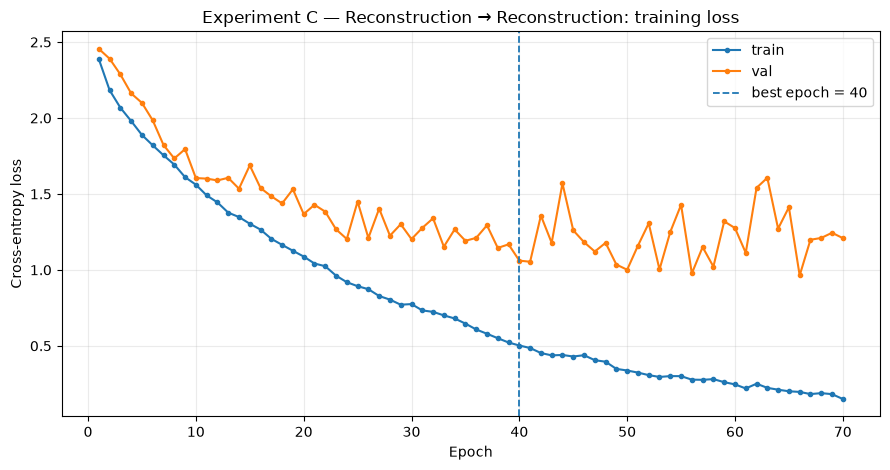

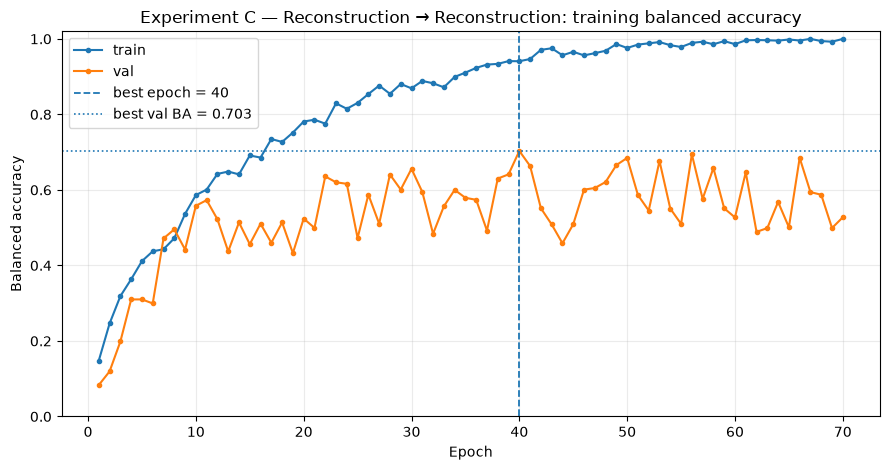

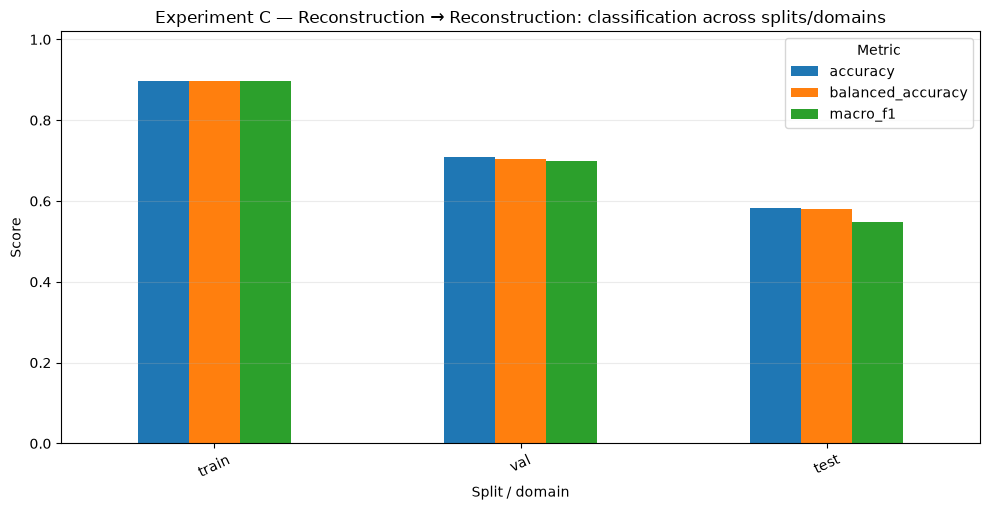

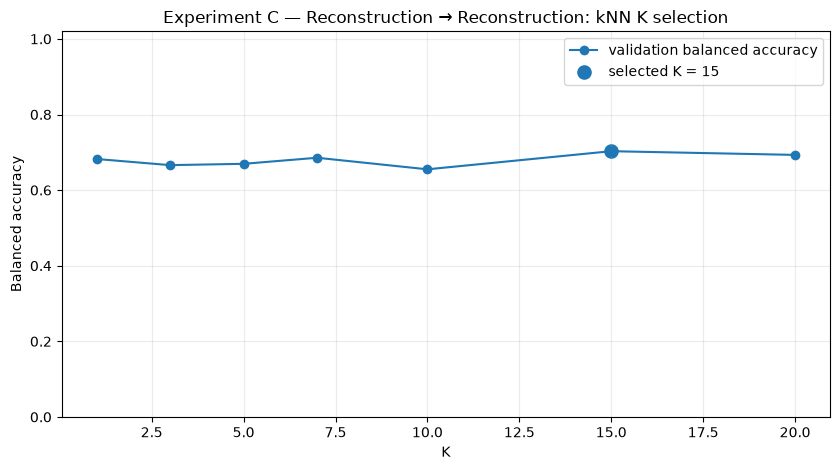

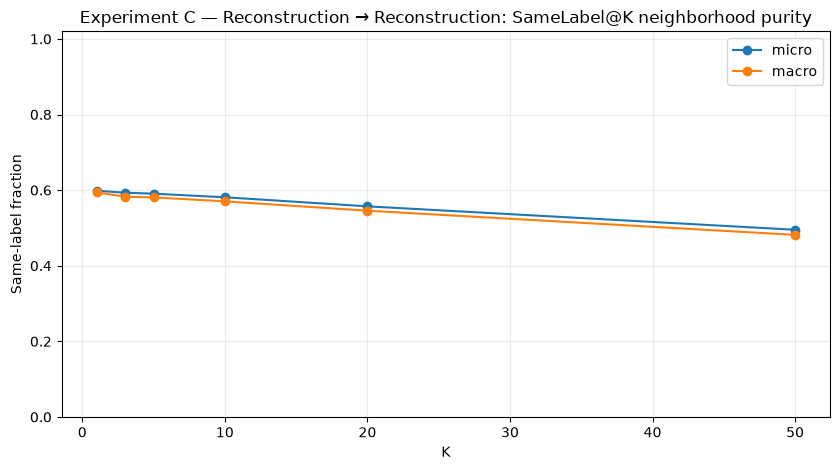

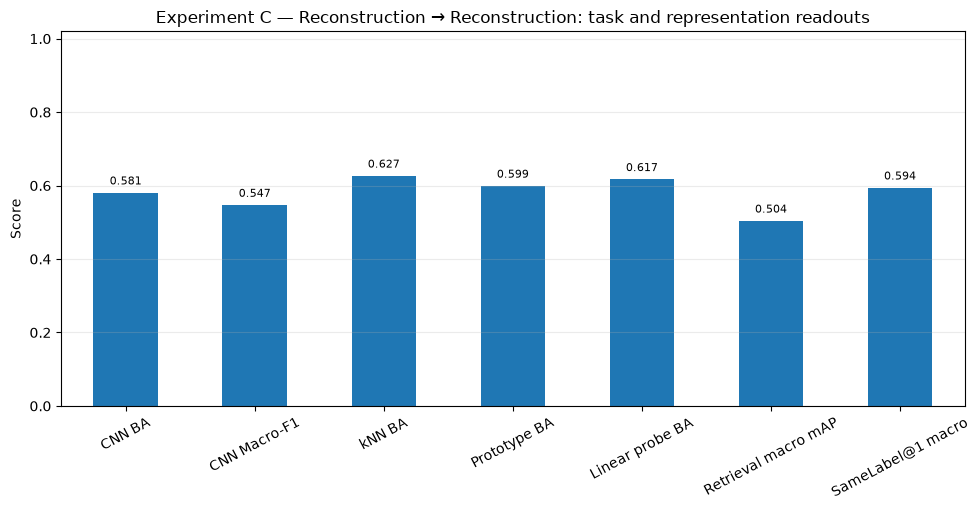

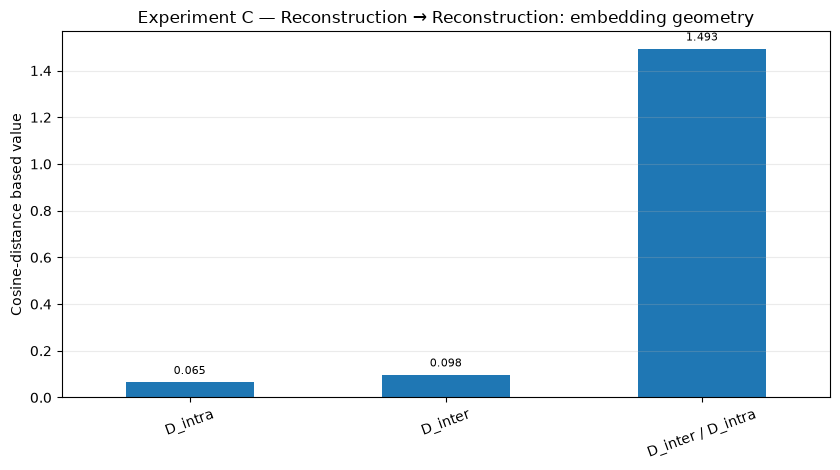

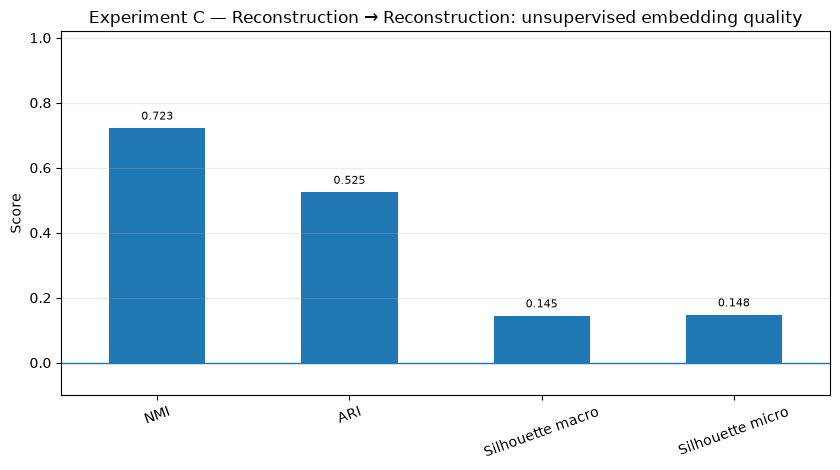

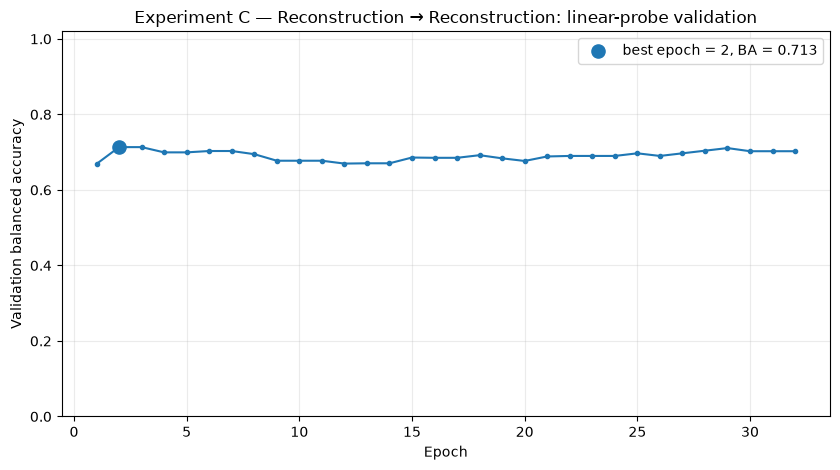

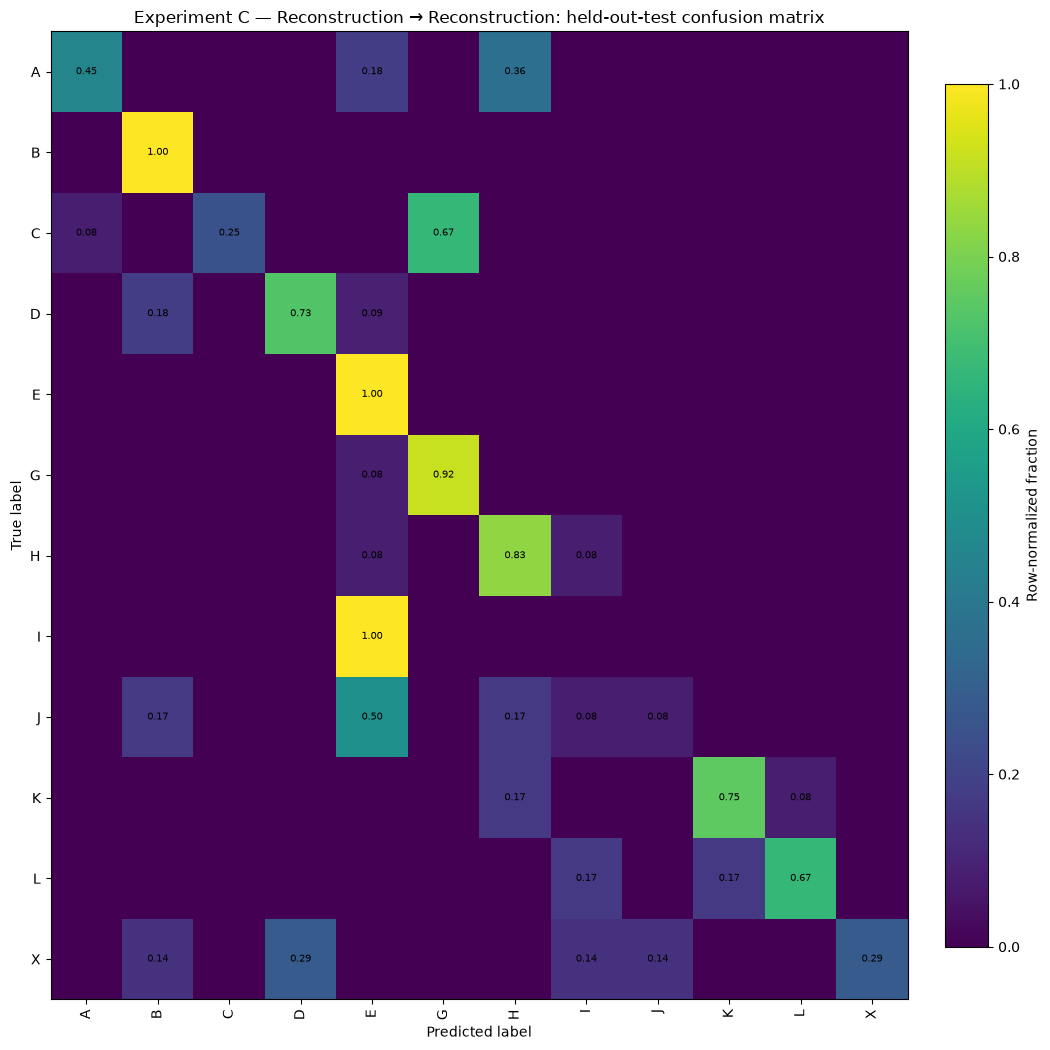

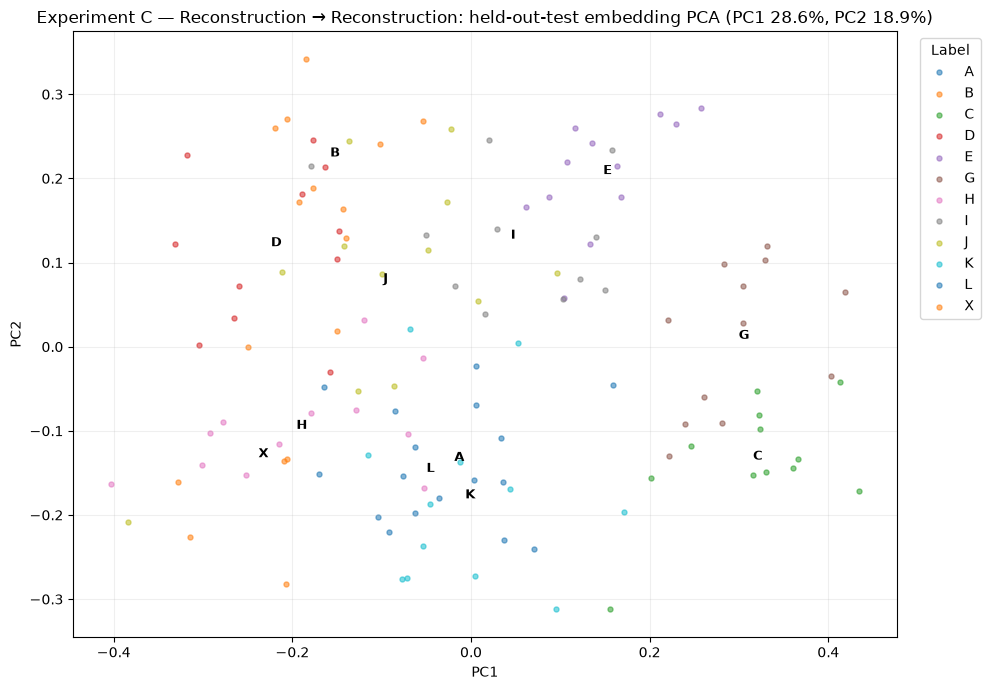

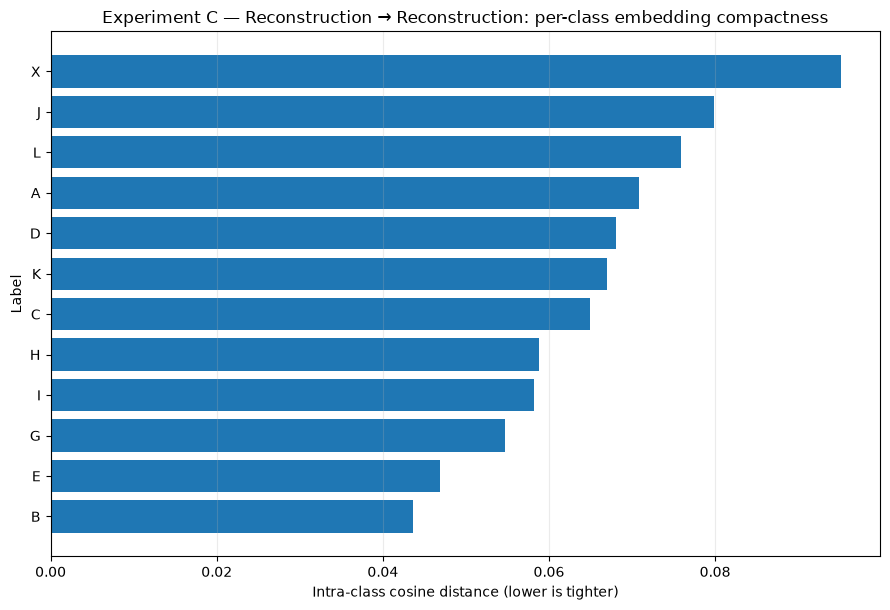

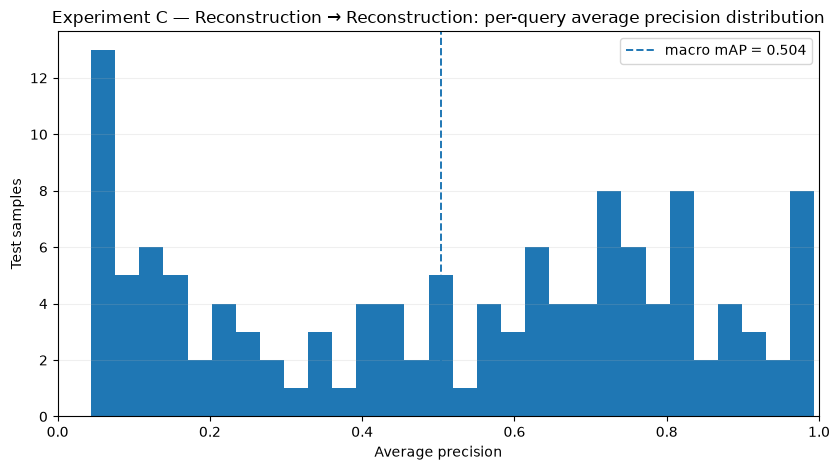

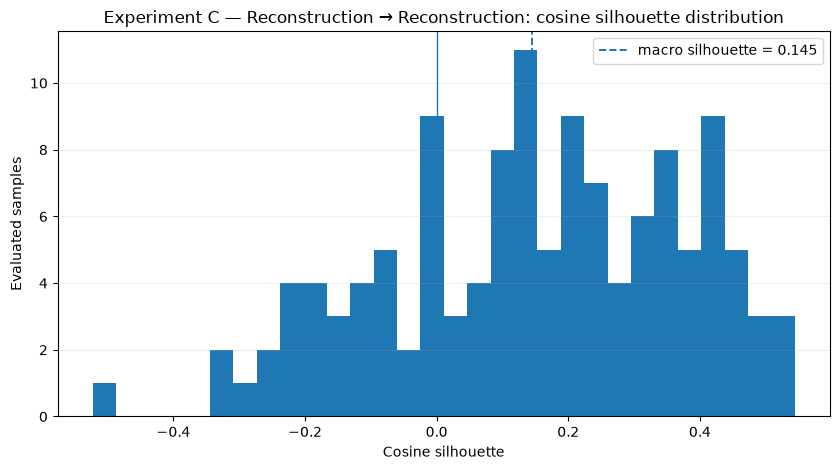

In [52]:
from snn.accel_reconstruction_eval.visualization import visualize_experiment_c

figures = visualize_experiment_c(run.output_dir)

## How to interpret C together with A and B

The key comparison is not B alone:

- **A high, B low, C approximately A:** reconstruction still contains task information; the main problem is raw-to-reconstruction domain shift.
- **A high, B low, C also low:** reconstruction has likely removed task-relevant information.
- **C > A:** reconstruction may provide a useful denoising or bottleneck effect; confirm this with geometry/retrieval metrics and repeated seeds before making a strong claim.

The final A/B/C comparison should use the same user split, class mapping, CNN architecture, and metric implementation.
